<a href="https://colab.research.google.com/github/ThinkingBeyond/BeyondAI-2025/blob/main/Iliyas%20Shaizada%20and%20Mourad%20Gad/elastic_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, sys
import numpy as np
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from IPython.display import Image, display

In [ ]:
print(sys.version)
print(np.__version__)
print(matplotlib.__version__)
print(sklearn.__version__)
!pip freeze

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
2.0.2
3.10.0
1.6.1
absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.11.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.2
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.11.0
anywidget==0.9.21
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.1.1
astropy-iers-data==0.2025.11.10.0.38.31
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.5
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.29.1
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.1.0
blosc2==3.11.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==5.5.2
catalogue==2.0.10
certifi==

# DATA GENERATION


In [ ]:
np.random.seed(20)
n_samples = 100
X = np.random.uniform(-1, 1, size=(n_samples, 1))
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(scale=1, size=n_samples)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# ELASTIC NET POLYNOMIAL REGRESSION RESULTS


In [ ]:
degrees = np.arange(1, 129)
train_errors = []
test_errors = []

os.makedirs("figures", exist_ok=True)

for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = ElasticNet(alpha=0.02, l1_ratio=0.2, max_iter=10000)  # ElasticNet with small regularization
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

    print(f"Degree {degree:3d} | Train MSE: {train_mse:.6f} | Test MSE: {test_mse:.6f}")
    sys.stdout.flush()

Degree   1 | Train MSE: 0.949556 | Test MSE: 2.342951
Degree   2 | Train MSE: 0.938464 | Test MSE: 2.369590
Degree   3 | Train MSE: 0.866460 | Test MSE: 2.187603
Degree   4 | Train MSE: 0.865656 | Test MSE: 2.172258
Degree   5 | Train MSE: 0.860255 | Test MSE: 2.147066
Degree   6 | Train MSE: 0.860217 | Test MSE: 2.142711
Degree   7 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree   8 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree   9 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  10 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  11 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  12 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  13 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  14 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  15 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  16 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  17 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  18 | Train MSE: 0.860610 | Test MSE: 2.139802
Degree  19 | Train MSE: 0.86

# BEHAVIOUR OF MODEL MSE WITH DEGREE RAISE

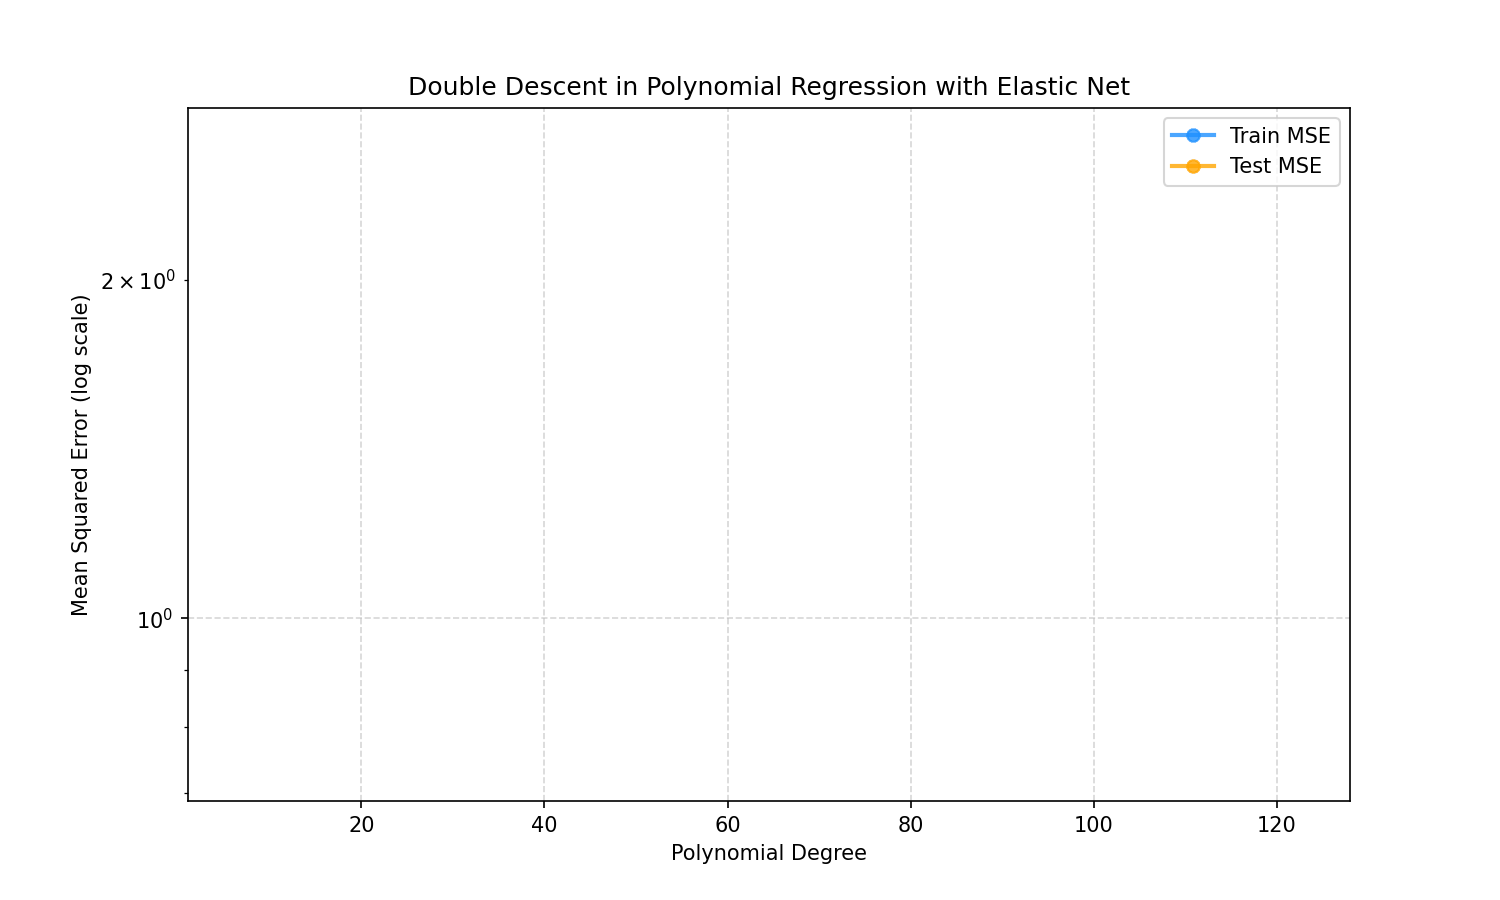

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(degrees[0], degrees[-1])
ax.set_yscale('log')

ax.set_ylim(
    min(min(train_errors), min(test_errors)) * 0.8,
    max(max(train_errors), max(test_errors)) * 1.2
)

ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("Mean Squared Error (log scale)")
ax.set_title("Double Descent in Polynomial Regression with Elastic Net")
ax.grid(True, linestyle='--', alpha=0.5)

line_train, = ax.plot([], [], 'o-', color='dodgerblue', label='Train MSE', lw=2, alpha=0.8)
line_test, = ax.plot([], [], 'o-', color='orange', label='Test MSE', lw=2, alpha=0.8)
ax.legend()

def init():
    line_train.set_data([], [])
    line_test.set_data([], [])
    return line_train, line_test

def update(frame):
    line_train.set_data(degrees[:frame], train_errors[:frame])
    line_test.set_data(degrees[:frame], test_errors[:frame])
    return line_train, line_test

ani = FuncAnimation(
    fig, update, frames=len(degrees), init_func=init,
    blit=True, interval=30
)

ani.save("double_descent_elanimation.gif", writer='pillow', dpi=150)
plt.close()

display(Image(filename="double_descent_elanimation.gif"))

# PLOTTING POLYNOMIAL CURVES WITH DIFFERENT L1_RATIOS

In [ ]:
X_curve = np.linspace(-1, 1, 100).reshape(-1, 1)
X_curve_poly = poly.transform(X_curve)

l1_ratios = [0.2, 0.4, 0.5, 0.7, 0.9]
colors = ['r', 'g', 'y', 'c', 'm']

curves = []

for i, l1_ratio in enumerate(l1_ratios): # Plotting Elastic Net regression with different l1_ratios
  reg = ElasticNet(alpha=0.02, l1_ratio=l1_ratio, max_iter=10000)
  reg.fit(X_train_poly, y_train)
  y_curve = reg.predict(X_curve_poly)
  curves.append(y_curve)

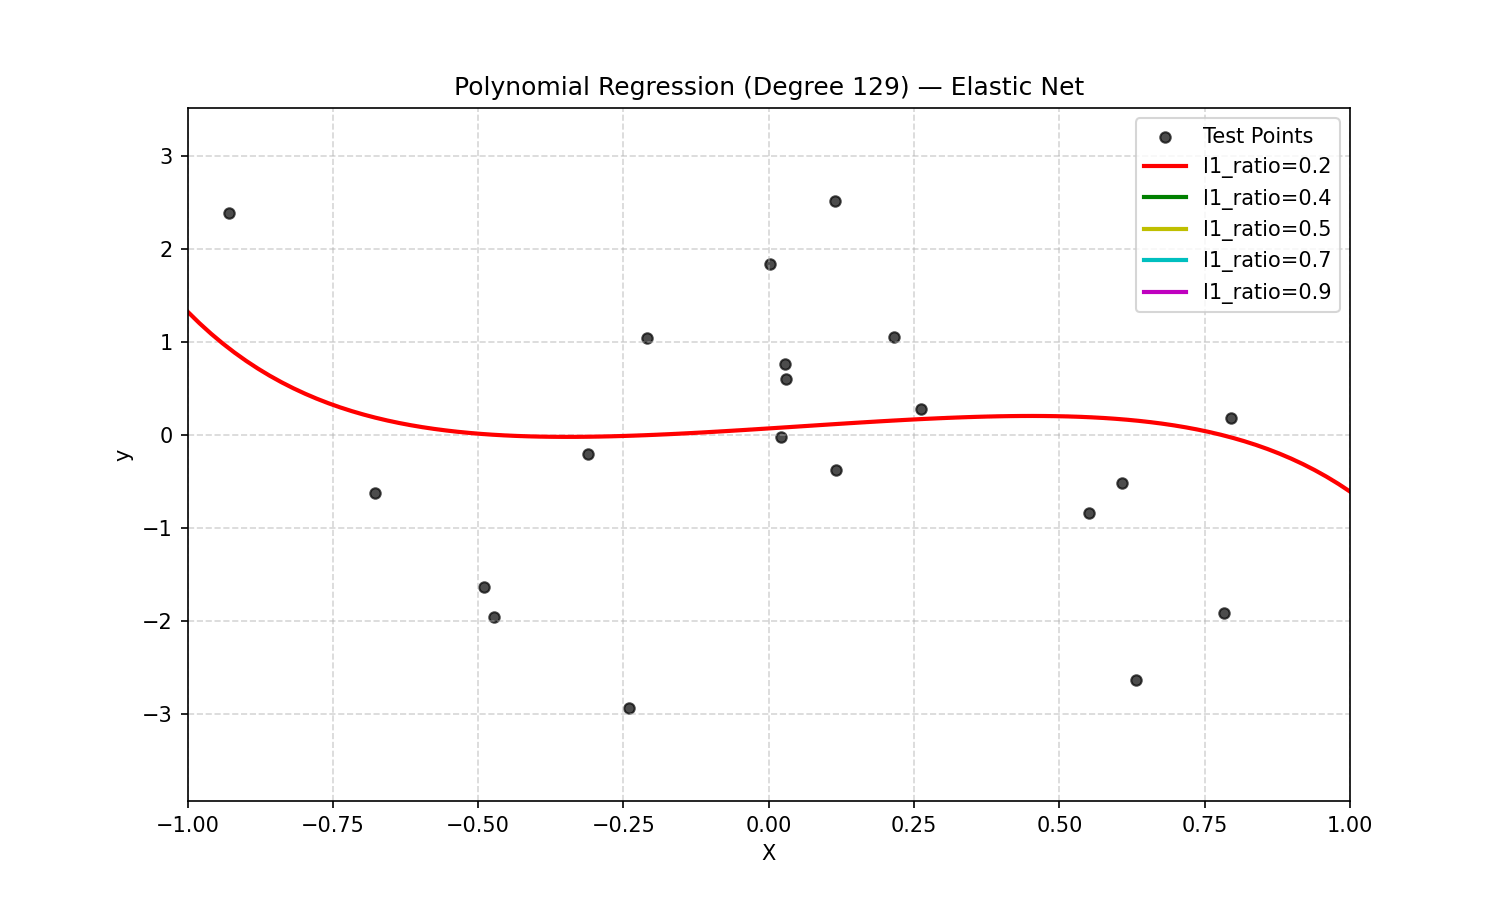

In [ ]:
# Plot curves
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_test, y_test, color='black', s=25, label="Test Points", alpha=0.7)

ax.set_xlim(-1, 1)
ax.set_ylim(min(y_test) - 1, max(y_test) + 1)
ax.set_title('Polynomial Regression (Degree 129) — Elastic Net')
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.grid(True, linestyle='--', alpha=0.5)

lines = []
for i in range(len(l1_ratios)):
    line, = ax.plot([], [], color=colors[i], lw=2, label=f"l1_ratio={l1_ratios[i]}")
    lines.append(line)

ax.legend()

def init():
    for line in lines:
        line.set_data([], [])
    return lines

def update(frame):
    # Reveal one full curve at each step
    for i in range(frame + 1):
        if i < len(lines):
            lines[i].set_data(X_curve, curves[i])
    return lines

ani = FuncAnimation(
    fig, update,
    frames=len(l1_ratios),
    init_func=init,
    blit=True,
    interval=600
)

# Save animation
ani.save("elasticnet_l1ratio_animation.gif", writer='pillow', dpi=150)
plt.close()

# Display animation
display(Image(filename="elasticnet_l1ratio_animation.gif"))